In [1]:
import os
import time
import math
import json
import pandas as pd
import numpy as np
import pylab as plt
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.markers import MarkerStyle

In [2]:
%load_ext autoreload
%autoreload 2
import src.count_utils as utils

In [3]:
import jupyter_black

jupyter_black.load()

In [4]:
plt.style.use("../src/mpl_style.txt")

In [5]:
VERSION = "research-article_aimrd_f"
BASELINE = "baseline_2026-01-23"
RESULTS_PATH = os.path.join("../data/results/", BASELINE, VERSION)
selection = ["delve", "crucial", "potential", "these", "significant", "important"]
start_date = "11-2017"
end_date = "12-2025"

os.makedirs(os.path.join("../results/plots", VERSION), exist_ok=True)

months = np.arange(1, 13)
years = np.arange(2000, 2025)

In [6]:
totals_m, totals_y = utils.get_totals(RESULTS_PATH, start_date, end_date)

In [7]:
sections = ["abstract", "introduction", "methods", "results", "discussion", "full"]
colors = dict(zip(sections, sns.color_palette("colorblind", len(sections))))
# change full color to make it less similar to introduction
colors["full"] = (0.541, 0.365, 0.224)

### Single words

In [40]:
sec = "abstract"
word = "delve"
freqs_df = pd.read_csv(
    os.path.join(RESULTS_PATH, sec, "freqs_df.csv.gz"),
    compression="gzip",
    index_col=0,
)
freqs_df = pd.DataFrame(freqs_df.loc[word]).T
freqs_df

,1-2000,2-2000,3-2000,4-2000,5-2000,6-2000,7-2000,8-2000,9-2000,10-2000,...,3-2025,4-2025,5-2025,6-2025,7-2025,8-2025,9-2025,10-2025,11-2025,12-2025
delve,0.011628,0.014085,0.011111,0.012821,0.010204,0.012195,0.018519,0.012821,0.010638,0.0125,...,0.001581,0.001382,0.001542,0.001332,0.00117,0.00089,0.000799,0.000751,0.000624,0.00067


In [41]:
start_split = start_date.split("-")
end_split = freqs_df.columns[-1].split("-")
x_months = np.arange(
    int(start_split[1]) + ((int(start_split[0]) - 1) / 12),
    int(end_split[1]) + ((int(end_split[0]) - 1) / 12),
    1 / 12,
)
freqs, proj, ratios, diffs, sdev = utils.frequency_projection(freqs_df, 60)
usage = diffs / (1 - proj)
df = pd.DataFrame(
    zip(x_months, freqs[0], proj[0], diffs[0], ratios[0], usage[0], sdev[0]),
    columns=["time", "frequency", "projection", "diff", "ratio", "usage", "sdev"],
)
n_m = [totals_m[math.floor(y)][round((y % 1) * 12)] for y in df["time"]]
df["regression se (ds)"] = list(
    map(
        utils.se,
        df["projection"],
        df["frequency"],
        n_m,
        ["regression"] * len(df),
        df["sdev"],
    )
)
df

1it [00:00, 302.93it/s]


,time,frequency,projection,diff,ratio,usage,sdev,regression se (ds)
0,2017.833333,0.000118,0.000170,-0.000052,0.692017,-0.000052,0.000102,0.000158
1,2017.916667,0.000254,0.000171,0.000083,1.484213,0.000083,0.000102,0.000201
2,2018.000000,0.000119,0.000173,-0.000053,0.691794,-0.000053,0.000102,0.000160
3,2018.083333,0.000126,0.000174,-0.000048,0.723130,-0.000048,0.000102,0.000160
4,2018.166667,0.000121,0.000175,-0.000055,0.689015,-0.000055,0.000102,0.000160
...,...,...,...,...,...,...,...,...
93,2025.583333,0.000890,0.000302,0.000588,2.949315,0.000588,0.000111,0.000259
94,2025.666667,0.000799,0.000303,0.000496,2.636021,0.000496,0.000111,0.000267
95,2025.750000,0.000751,0.000304,0.000446,2.465959,0.000446,0.000111,0.000269
96,2025.833333,0.000624,0.000306,0.000318,2.038468,0.000318,0.000111,0.000243


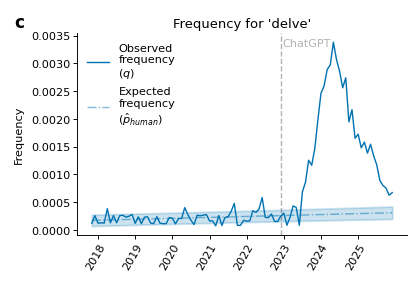

In [51]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3, 2), layout="constrained")

ax.axvline(x=2022 + (11 / 12), linestyle="--", color="black", alpha=0.3)
ax.text(
    x=2022 + (11 / 12) + 0.05, y=0.0033, s="ChatGPT", color="black", alpha=0.3
)  # delve: y=0.0033 these: y=0.5 potential: y=0.268

sns.lineplot(
    data=df,
    x="time",
    y="frequency",
    ax=ax,
    color=colors[sec],
    label="Observed\nfrequency\n($q$)",
)
sns.lineplot(
    data=df,
    x="time",
    y="projection",
    ax=ax,
    color=colors[sec],
    alpha=0.5,
    linestyle="-.",
    label="Expected\nfrequency\n($\\hat{p}_{human}$)",
)
ax.fill_between(
    df["time"],
    df["projection"] - df["sdev"],
    df["projection"] + df["sdev"],
    alpha=0.2,
    color=colors[sec],
)


ax.set_xlabel(None)
ax.set_xticks(range(2018, 2026))
ax.set_xticklabels(range(2018, 2026), rotation=60, ha="right", rotation_mode="anchor")
ax.set_ylabel("Frequency")
ax.set_title(f"Frequency for '{word}'")
ax.text(
    -0.19,
    1.1,
    "c",
    transform=ax.transAxes,
    fontsize=9,
    fontweight="bold",
    va="top",
)
plt.savefig(
    os.path.join("../results/plots", BASELINE, VERSION, f"{word}_freqs_time.png"),
    dpi=300,
)

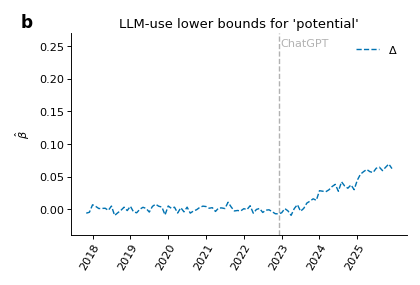

In [36]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3, 2), layout="constrained")

ax.axvline(x=2022 + (11 / 12), linestyle="--", color="black", alpha=0.3)
ax.text(x=2022 + (11 / 12) + 0.05, y=0.25, s="ChatGPT", color="black", alpha=0.3)

sns.lineplot(
    data=df,
    x="time",
    y="diff",
    ax=ax,
    color=colors[sec],
    linestyle="--",
    label="$\\Delta$",
)

ax.set_xlabel(None)
ax.set_xticks(range(2018, 2026))
ax.set_xticklabels(range(2018, 2026), rotation=60, ha="right", rotation_mode="anchor")
ax.set_ylim(-0.04, 0.27)
ax.set_ylabel("$\\hat{\\beta}$")
ax.set_title(f"LLM-use lower bounds for '{word}'")

ax.text(
    -0.15,
    1.1,
    "b",
    transform=ax.transAxes,
    fontsize=9,
    fontweight="bold",
    va="top",
)

plt.savefig(
    os.path.join("../results/plots", BASELINE, VERSION, f"{word}_diff_time.png"),
    dpi=300,
)

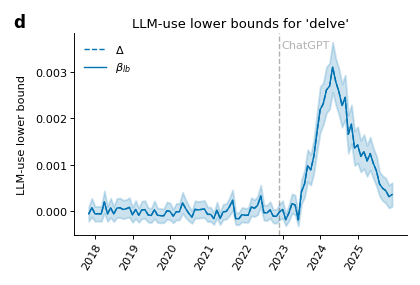

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3, 2), layout="constrained")

ax.axvline(x=2022 + (11 / 12), linestyle="--", color="black", alpha=0.3)
ax.text(
    x=2022 + (11 / 12) + 0.05, y=0.0035, s="ChatGPT", color="black", alpha=0.3
)  # these: y=0.25 potential: y=0.135 delve: y=0.0035

sns.lineplot(
    data=df,
    x="time",
    y="diff",
    ax=ax,
    color=colors[sec],
    linestyle="--",
    label="$\\Delta$",
)
sns.lineplot(
    data=df,
    x="time",
    y="usage",
    ax=ax,
    color=colors[sec],
    label="$\\beta_{lb}$",
)
ax.fill_between(
    df["time"],
    df["usage"] - df["regression se (ds)"],
    df["usage"] + df["regression se (ds)"],
    alpha=0.2,
    color=colors[sec],
)

ax.text(
    -0.18,
    1.1,
    "d",
    transform=ax.transAxes,
    fontsize=9,
    fontweight="bold",
    va="top",
)

ax.legend(loc="upper left")
ax.set_xlabel(None)
ax.set_xticks(range(2018, 2026))
ax.set_xticklabels(range(2018, 2026), rotation=60, ha="right", rotation_mode="anchor")
# ax.set_ylim(-0.04, 0.148)
ax.set_ylabel("LLM-use lower bound")
ax.set_title(f"LLM-use lower bounds for '{word}'")


plt.savefig(
    os.path.join("../results/plots", BASELINE, VERSION, f"{word}_usage_time.png"),
    dpi=300,
)

In [ ]:
"""
frequency_dfs = utils.load_freqs(RESULTS_PATH, selection, start_date)
freq_dfs_agg = {}

for word, df in frequency_dfs.items():
    df = df.copy()
    df["time"] = list(map(math.floor, df["time"]))
    df = df.groupby(["time", "section"]).mean().reset_index()
    df["section"] = pd.Categorical(
        df["section"],
        categories=[
            "abstract",
            "introduction",
            "methods",
            "results",
            "discussion",
            "full",
        ],
        ordered=True,
    )

    freq_dfs_agg[word] = df
"""

In [ ]:
"""fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(7, 4.5), layout="constrained")

for i, word in enumerate(selection):
    ax = axs.flat[i]
    ax.axvline(x=2022 + (11 / 12), linestyle="--", color="black", alpha=0.3)
    sns.lineplot(
        data=frequency_dfs[word], x="time", y="frequency", hue="section", ax=ax
    )
    sns.lineplot(
        data=frequency_dfs[word],
        x="time",
        y="projection",
        hue="section",
        ax=ax,
        alpha=0.5,
        linestyle="-.",
        legend=False,
    )
    ax.set_title(word)
    ax.set_xlabel(None)
    if i < 3:
        ax.set_xticks([2021, 2022, 2023, 2024, 2025])
        ax.set_xticklabels([])
    else:
        ax.set_xticks([2021, 2022, 2023, 2024, 2025])
        ax.set_xticklabels([2021, 2022, 2023, 2024, 2025], rotation=60)
    if i not in [0, 3]:
        ax.set_ylabel(None)
    if not i == 0:
        ax.get_legend().set_visible(False)

plt.savefig(os.path.join("../results/plots", VERSION, "word_freqs_time.png"), dpi=300)
"""

In [ ]:
"""fig, axs = plt.subplots(nrows=2, ncols=6, figsize=(10, 4), layout="constrained")

for i, word in enumerate(selection):

    # plot diffs
    ax = axs[0, i]
    ax.axvline(x=2022 + (11 / 12), linestyle="--", color="black", alpha=0.3)
    sns.lineplot(data=frequency_dfs[word], x="time", y="diff", hue="section", ax=ax)

    # plot ratios
    ax = axs[1, i]
    ax.axvline(x=2022 + (11 / 12), linestyle="--", color="black", alpha=0.3)
    sns.lineplot(data=frequency_dfs[word], x="time", y="ratio", hue="section", ax=ax)

    for j in range(2):
        ax = axs[j, i]
        ax.set_xlabel(None)
        if j == 0:
            ax.set_title(word)
        if j == 1:
            ax.set_xticks([2021, 2022, 2023, 2024, 2025])
            ax.set_xticklabels([2021, 2022, 2023, 2024, 2025], rotation=60)
        else:
            ax.set_xticks([2021, 2022, 2023, 2024, 2025])
            ax.set_xticklabels([])
        if not i == 0:
            ax.set_ylabel(None)
        if not (i == 0 and j == 0):
            ax.get_legend().set_visible(False)

plt.savefig(os.path.join("../results/plots", VERSION, "word_diff_ratio.png"), dpi=300)
"""

is there a way to standardize between sections? bc the longer a section is, the more likely it is that a word occurs? or give mean word counts per sections?

In [ ]:
"""fig, axs = plt.subplots(nrows=2, ncols=6, figsize=(8, 4), layout="constrained")

for i, word in enumerate(selection):

    # plot diffs
    ax = axs[0, i]
    sns.pointplot(data=freq_dfs_agg[word], x="section", y="diff", hue="time", ax=ax)

    # plot ratios
    ax = axs[1, i]
    sns.pointplot(data=freq_dfs_agg[word], x="section", y="ratio", hue="time", ax=ax)

    for j in range(2):
        ax = axs[j, i]
        ax.set_xlabel(None)
        if j == 0:
            ax.set_title(word)
        if j == 1:
            ax.set_xticklabels(
                freq_dfs_agg["potential"]["section"].cat.categories, rotation=60
            )
        else:
            ax.set_xticklabels([])
        if not i == 0:
            ax.set_ylabel(None)
        if not (i == 0 and j == 0):
            ax.get_legend().set_visible(False)

plt.savefig(
    os.path.join("../results/plots", VERSION, "word_freqs_section.png"), dpi=300
)"""

### Word groups

In [8]:
group_frequency_dfs_m = utils.load_freqs(
    data_path=RESULTS_PATH,
    group_prefix="group_",
    start_date=start_date,
    end_date=end_date,
)

In [9]:
t = group_frequency_dfs_m["rare_words"]["time"]
n_m = [totals_m[math.floor(y)][round((y % 1) * 12)] for y in t]

for w in ["common_words", "rare_words"]:
    p = group_frequency_dfs_m[w]["projection"]
    q = group_frequency_dfs_m[w]["frequency"]
    reg_se = group_frequency_dfs_m[w]["sdev"]
    se = list(map(utils.se, p, q, n_m, ["regression"] * len(p), reg_se))
    group_frequency_dfs_m[w]["regression se (ds)"] = se

In [17]:
group_frequency_dfs_m["rare_words"]["time"]

0      2017.833333
1      2017.833333
2      2017.833333
3      2017.833333
4      2017.833333
          ...     
583    2025.916667
584    2025.916667
585    2025.916667
586    2025.916667
587    2025.916667
Name: time, Length: 588, dtype: float64

In [20]:
group_frequency_dfs_m["rare_words"][
    group_frequency_dfs_m["rare_words"]["time"] > 2025.9
][["section", "usage"]]

,section,usage
582,full,0.404534
583,methods,0.317632
584,discussion,0.676779
585,results,0.456435
586,introduction,0.593459
587,abstract,0.665961


In [ ]:
group_frequency_dfs_y = utils.load_freqs(
    data_path=RESULTS_PATH,
    group_prefix="group_",
    start_date="2018",
    end_date="2025",
    pred_range=5,
)

In [ ]:
t = group_frequency_dfs_y["rare_words"]["time"]
n_y = [totals_y[y] for y in t]

for w in ["common_words", "rare_words"]:
    p = group_frequency_dfs_y[w]["projection"]
    q = group_frequency_dfs_y[w]["frequency"]
    reg_se = group_frequency_dfs_y[w]["sdev"]
    se = list(map(utils.se, p, q, n_y, ["regression"] * len(p), reg_se))
    group_frequency_dfs_y[w]["regression se (ds)"] = se

In [ ]:
for w in ["rare_words", "common_words"]:
    group_frequency_dfs_y[w]["section"] = pd.Categorical(
        group_frequency_dfs_y[w]["section"],
        categories=[
            "abstract",
            "introduction",
            "methods",
            "results",
            "discussion",
            "full",
        ],
        ordered=True,
    )

In [ ]:
#### Old version

fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(5, 5), layout="constrained")

for j, var in enumerate(["frequency", "diff", "ratio"]):
    for i, group in enumerate(group_frequency_dfs_m.keys()):
        ax = axs[j, i]
        ax.axvline(x=2022 + (11 / 12), linestyle="--", color="black", alpha=0.3)
        sns.lineplot(
            data=group_frequency_dfs_m[group],
            x="time",
            y=var,
            hue="section",
            ax=ax,
        )
        if var == "frequency":
            sns.lineplot(
                data=group_frequency_dfs_m[group],
                x="time",
                y="projection",
                hue="section",
                ax=ax,
                alpha=0.5,
                linestyle="-.",
                legend=False,
            )

        ax.set_xlabel(None)
        if j == 0:
            ax.set_title(group)
            ax.set_ylim(0.15, 1.05)
        if j == 1:
            ax.set_ylim(-0.025, 0.25)
        if j == 2:
            ax.set_ylim(0.96, 1.7)
            ax.set_xticks([2021, 2022, 2023, 2024, 2025])
            ax.set_xticklabels([2021, 2022, 2023, 2024, 2025], rotation=60)
        else:
            ax.set_xticks([2021, 2022, 2023, 2024, 2025])
            ax.set_xticklabels([])
        if not i == 0:
            ax.set_ylabel(None)
        if not (i == 1 and j == 2):
            ax.get_legend().set_visible(False)

        axs[1, 0].axhline(
            y=0.22, color="black", linestyle="dotted", alpha=0.8
        )  # common
        axs[1, 1].axhline(y=0.18, color="black", linestyle="dotted", alpha=0.8)  # rare

plt.savefig(
    os.path.join(
        "../results/plots",
        BASELINE,
        VERSION,
        "group_freqs_time_old_version.png",
    ),
    dpi=300,
)

In [ ]:
# old version
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(7, 5), layout="constrained")

for j, var in enumerate(["frequency", "usage", "diff"]):
    for i, group in enumerate(group_frequency_dfs_m.keys()):
        df = group_frequency_dfs_m[group]
        ax = axs[j, i]
        ax.axvline(x=2022 + (11 / 12), linestyle="--", color="black", alpha=0.3)
        sns.lineplot(
            data=df,
            x="time",
            y=var,
            hue="section",
            palette=colors,
            hue_order=sections,
            ax=ax,
        )
        if var == "frequency":
            sns.lineplot(
                data=df,
                x="time",
                y="projection",
                hue="section",
                palette=colors,
                ax=ax,
                alpha=0.5,
                linestyle="-.",
                legend=False,
            )

        if var == "usage":
            for sec in df["section"].unique():
                ax.fill_between(
                    df[df["section"] == sec]["time"],
                    df[df["section"] == sec]["usage"]
                    - df[df["section"] == sec]["regression se (ds)"],
                    df[df["section"] == sec]["usage"]
                    + df[df["section"] == sec]["regression se (ds)"],
                    alpha=0.2,
                    color=colors[sec],
                )

        ax.set_xlabel(None)
        if j == 0:
            ax.set_title(group)
            ax.set_ylim(0.15, 1.05)
        if j == 1:
            ax.set_ylim(-0.2, 1.05)
        if j == 2:
            ax.set_ylim(-0.05, 1.05)
            ax.set_xticks(range(2018, 2026))
            ax.set_xticklabels(range(2018, 2026), rotation=60)
        else:
            ax.set_xticks(range(2018, 2026))
            ax.set_xticklabels([])
        if not i == 0:
            ax.set_ylabel(None)
        if not (i == 1 and j == 2):
            ax.get_legend().set_visible(False)


plt.savefig(
    os.path.join(
        "../results/plots",
        BASELINE,
        VERSION,
        "group_freqs_time_old_version.png",
    ),
    dpi=300,
)

In [ ]:
# new version
df = group_frequency_dfs_m["rare_words"]
df = df[df["time"] >= 2020]

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(4, 4), layout="constrained")

for i, var in enumerate(["frequency", "usage"]):

    ax = axs[i]
    ax.axvline(x=2022 + (11 / 12), linestyle="--", color="black", alpha=0.3)
    sns.lineplot(
        data=df,
        x="time",
        y=var,
        hue="section",
        palette=colors,
        hue_order=sections,
        ax=ax,
    )

    if i == 0:
        sns.lineplot(
            data=df,
            x="time",
            y="projection",
            hue="section",
            palette=colors,
            ax=ax,
            alpha=0.5,
            linestyle="-.",
            legend=False,
        )
    ax.set_xlabel(None)
    ax.set_xticks(range(2020, 2026))

y_adjustment_text = dict(zip(sections, [0.015, -0.005, -0.035, -0.01, 0, 0]))
for sec in df["section"].unique():
    axs[1].fill_between(
        df[df["section"] == sec]["time"],
        df[df["section"] == sec]["usage"]
        - df[df["section"] == sec]["regression se (ds)"],
        df[df["section"] == sec]["usage"]
        + df[df["section"] == sec]["regression se (ds)"],
        alpha=0.2,
        color=colors[sec],
    )
    """
    dec_25 = list(df[df["section"] == sec]["usage"])[-1]
    plt.text(
        x=2026 - 0.05,
        y=dec_25 + y_adjustment_text[sec],
        s=f"{dec_25:.2f}",
        fontdict={"fontsize": 7},
        color=colors[sec],
    )
    """

axs[0].get_legend().set_visible(False)
axs[0].set_xticklabels([])
axs[1].set_xticklabels(range(2020, 2026), rotation=60)
axs[0].set_ylabel("Frequency")
ax.set_ylabel("Estimated LLM-use ($\\hat{\\beta}$)")
axs[0].set_ylim(0.7, 1.0)
axs[1].set_ylim(-0.2, 1.0)

plt.savefig(
    os.path.join(
        "../results/plots",
        BASELINE,
        VERSION,
        "group_freqs_time.png",
    ),
)

In [ ]:
df = group_frequency_dfs_m["rare_words"]
df = df[df["time"] >= 2020]

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 3), layout="constrained")

ax.axvline(x=2022 + (11 / 12), linestyle="--", color="black", alpha=0.3)
sns.lineplot(
    data=df,
    x="time",
    y="usage",
    hue="section",
    palette=colors,
    hue_order=sections,
    ax=ax,
)

y_adjustment_text = dict(zip(sections, [0.015, -0.005, -0.035, -0.01, 0, 0]))
for sec in df["section"].unique():
    ax.fill_between(
        df[df["section"] == sec]["time"],
        df[df["section"] == sec]["usage"]
        - df[df["section"] == sec]["regression se (ds)"],
        df[df["section"] == sec]["usage"]
        + df[df["section"] == sec]["regression se (ds)"],
        alpha=0.2,
        color=colors[sec],
    )
    dec_25 = list(df[df["section"] == sec]["usage"])[-1]
    plt.text(
        x=2026 - 0.05,
        y=dec_25 + y_adjustment_text[sec],
        s=f"{dec_25:.2f}",
        fontdict={"fontsize": 7},
        color=colors[sec],
    )


ax.set_xlabel(None)
ax.set_xticks(range(2020, 2026))
ax.set_xticklabels(range(2020, 2026), rotation=60)
ax.set_ylabel("Estimated LLM-use ($\\hat{\\beta}$)")
ax.set_ylim(-0.2, 1.0)

ax.set_title("LLM-use estimate per month")


plt.savefig(
    os.path.join(
        "../results/plots",
        BASELINE,
        VERSION,
        "group_usage_time.png",
    ),
)

In [ ]:
list(df[df["section"] == sec]["usage"])[-1]

In [ ]:
# old version
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(4, 4), layout="constrained")

for i, group in enumerate(group_frequency_dfs_y.keys()):

    # plot ratios
    ax = axs[0, i]
    sns.pointplot(
        data=group_frequency_dfs_y[group], x="section", y="usage", hue="time", ax=ax
    )

    # plot diffs
    ax = axs[1, i]
    sns.pointplot(
        data=group_frequency_dfs_y[group], x="section", y="diff", hue="time", ax=ax
    )

    for j in range(2):
        ax = axs[j, i]
        ax.set_xlabel(None)
        if j == 0:
            ax.set_title(group)
            # ax.set_ylim(-0.025, 0.25)
        if j == 1:
            # ax.set_ylim(0.96, 1.7)
            ax.set_xticklabels(
                group_frequency_dfs_y["common_words"]["section"].cat.categories,
                rotation=60,
            )
        else:
            ax.set_xticklabels([])
        if not i == 0:
            ax.set_ylabel(None)
        if not (i == 1 and j == 1):
            ax.get_legend().set_visible(False)


plt.savefig(
    os.path.join(
        "../results/plots", BASELINE, VERSION, "group_freqs_section_old_version.png"
    ),
    dpi=300,
)

In [ ]:
# new version
df = group_frequency_dfs_y["rare_words"]
palette = "flare"
cmap = plt.cm.get_cmap(palette)
norm = mcolors.Normalize(vmin=df["time"].min(), vmax=df["time"].max())

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(2.5, 2.5), layout="constrained")

sns.pointplot(
    data=df,
    x="section",
    y="usage",
    hue="time",
    ax=ax,
    palette=palette,
    markersize=2.5,
    linestyles="none",
)

for _, row in df.iterrows():
    x = df["section"].cat.categories.get_loc(row["section"])
    color = cmap(norm(row["time"]))

    ax.errorbar(
        x=x,
        y=row["usage"],
        yerr=row["regression se (ds)"],
        fmt="none",
        ecolor=color,
        capsize=2,
        linewidth=0.8,
    )

ax.set_xlabel(None)
ax.set_xticklabels(
    df["section"].cat.categories,
    rotation=60,
    ha="right",
    rotation_mode="anchor",
)

ax.set_ylim(-0.1, 1.0)
ax.set_ylabel("Estimated LLM-use ($\\hat{\\beta}$)")
ax.get_legend().set_visible(False)

"""
sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
cax = fig.add_axes(
    [
        ax.get_position().x1 + 0.1,
        ax.get_position().y0 + 0.1,
        0.05,
        ax.get_position().height,
    ]
)
ax.figure.colorbar(sm, cax=cax)
"""
ax.text(
    -0.15,
    1.1,
    "a",
    transform=ax.transAxes,
    fontsize=9,
    fontweight="bold",
    va="top",
)

ax.set_title("Full-length sections")

plt.savefig(
    os.path.join(
        "../results/plots", BASELINE, VERSION, "group_freqs_section_single_panel.png"
    ),
    dpi=300,
    bbox_inches="tight",
)

### Overview plots with results from other studies

In [10]:
review = {
    "date": [
        2023,
        2023.58,
        2023.83,
        2023.41,
        2023.5,
        2023.5,
        2023.5,
        2024,
        2024.08,
        2024.08,
        2024.08,
        2024.08,
        2024.67,
        2024.67,
        2024.67,
        2024.67,
        2024.41,
        2024.5,
        2024.58,
        2023.33,
        2023.45,
        2023.55,
        2023.66,
        2024.03,
        2024.03,
        2024.15,
        2024.15,
        2024.15,
        2024.20,
        2024.20,
        2024.25,
        2024.25,
        2024.25,
        2024.25,
        2024.33,
        2024.33,
        2025.58,
    ],
    "section": [
        "abstract",
        "abstract",
        "full",
        "full",
        "abstract",
        "abstract",
        "abstract",
        "abstract",
        "abstract",
        "introduction",
        "abstract",
        "introduction",
        "abstract",
        "introduction",
        "abstract",
        "introduction",
        "abstract",
        "full",
        "full",
        None,
        None,
        None,
        None,
        None,
        None,
        None,
        None,
        None,
        None,
        None,
        None,
        None,
        None,
        None,
        None,
        None,
        None,
    ],
    "LLM-use": [
        0.10,
        0.13,
        0.07,
        0.02,
        0.07,
        0.04,
        0.69,
        0.35,
        0.18,
        0.14,
        0.06,
        0.04,
        0.23,
        0.20,
        0.09,
        0.09,
        0.14,
        0.12,
        0.16,
        0.27,
        0.2,
        0.22,
        0.21,
        0.5,
        0.43,
        0.16,
        0.17,
        0.18,
        0.4,
        0.38,
        0.28,
        0.08,
        0.08,
        0.08,
        0.08,
        0.08,
        0.71,
    ],
    "mode": [
        "commercial",
        "trained detector",
        "commercial",
        "word frequency",
        "commercial",
        "commercial",
        "commercial",
        "word freq. modeling",
        "word freq. modeling",
        "word freq. modeling",
        "word freq. modeling",
        "word freq. modeling",
        "word freq. modeling",
        "word freq. modeling",
        "word freq. modeling",
        "word freq. modeling",
        "word frequency",
        "word frequency",
        "word frequency",
        "writing",
        "editing",
        "both",
        "writing",
        "editing",
        "writing",
        "writing",
        "editing",
        "writing",
        "writing",
        "editing",
        "editing",
        "writing",
        "writing",
        "writing",
        "writing",
        "editing",
        "both",
    ],
    "source": [
        "Picazo-Sanchez (2023)",
        "Bao (2025)",
        "Akram (2024)",
        "Gray (2025)",
        "Liu (2024)",
        "Liu (2024)",
        "Liu (2024)",
        "Geng (2025)",
        "Liang (2024)",
        "Liang (2024)",
        "Liang (2024)",
        "Liang (2024)",
        "Liang (2025)",
        "Liang (2025)",
        "Liang (2025)",
        "Liang (2025)",
        "Kobak (2025)",
        "Gray (2026)",
        "Kousha (2025)",
        "Eppler (2024)",
        "Nordling (2023)",
        "Ng (2025)",
        "Van Noorden (2023)",
        "Liao (2024)",
        "Liao (2024)",
        "Mohammadi (2026)",
        "Mohammadi (2026)",
        "Mohammadi (2026)",
        "Wiley (2025)",
        "Wiley (2025)",
        "Kwon (2025)",
        "Kwon (2025)",
        "Kwon (2025)",
        "Kwon (2025)",
        "Mishra (2024)",
        "Mishra (2024)",
        "Wiley (2026)",
    ],
    "method": ["estimate"] * 19 + ["survey"] * 18,
    "annotate": [
        True,
        True,
        True,
        True,
        False,
        True,
        False,
        True,
        False,
        False,
        False,
        True,
        True,
        False,
        False,
        False,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        False,
        False,
        False,
        True,
        True,
        False,
        True,
        False,
        False,
        False,
        True,
        False,
        True,
    ],
    "ha": [
        "left",
        "left",
        "left",
        "right",
        "left",
        "left",
        "left",
        "right",
        "left",
        "left",
        "left",
        "left",
        "left",
        "left",
        "left",
        "left",
        "right",
        "left",
        "left",
        "left",
        "right",
        "center",
        "left",
        "left",
        "left",
        "left",
        "left",
        "left",
        "left",
        "left",
        "left",
        "left",
        "left",
        "left",
        "left",
        "left",
        "left",
    ],
    "va": [
        "bottom",
        "top",
        "bottom",
        "bottom",
        "bottom",
        "bottom",
        "bottom",
        "bottom",
        "top",
        "top",
        "top",
        "top",
        "bottom",
        "bottom",
        "bottom",
        "bottom",
        "top",
        "bottom",
        "bottom",
        "bottom",
        "bottom",
        "bottom",
        "bottom",
        "bottom",
        "bottom",
        "bottom",
        "bottom",
        "bottom",
        "bottom",
        "bottom",
        "bottom",
        "bottom",
        "bottom",
        "bottom",
        "top",
        "top",
        "bottom",
    ],
}

In [11]:
review_df = pd.DataFrame(review, columns=review.keys())
review_df

,date,section,LLM-use,mode,source,method,annotate,ha,va
0,2023.00,abstract,0.10,commercial,Picazo-Sanchez (2023),estimate,True,left,bottom
1,2023.58,abstract,0.13,trained detector,Bao (2025),estimate,True,left,top
2,2023.83,full,0.07,commercial,Akram (2024),estimate,True,left,bottom
3,2023.41,full,0.02,word frequency,Gray (2025),estimate,True,right,bottom
4,2023.50,abstract,0.07,commercial,Liu (2024),estimate,False,left,bottom
5,2023.50,abstract,0.04,commercial,Liu (2024),estimate,True,left,bottom
6,2023.50,abstract,0.69,commercial,Liu (2024),estimate,False,left,bottom
7,2024.00,abstract,0.35,word freq. modeling,Geng (2025),estimate,True,right,bottom
8,2024.08,abstract,0.18,word freq. modeling,Liang (2024),estimate,False,left,top
9,2024.08,introduction,0.14,word freq. modeling,Liang (2024),estimate,False,left,top


In [12]:
n_est = 11
n_sur = 10

cmap_est = plt.cm.autumn
cmap_sur = plt.cm.winter
# Sample avoiding too light colors
rng = np.random.default_rng(0)
est_colors = cmap_est(np.linspace(0.0, 1.0, n_est))
sur_colors = cmap_sur(np.linspace(0.0, 0.9, n_sur))
rng.shuffle(est_colors)
rng.shuffle(sur_colors)

colordict = dict(
    zip(
        list(review_df[review_df["method"] == "estimate"]["source"].unique()),
        est_colors,
    )
)
colordict |= dict(
    zip(
        list(review_df[review_df["method"] == "survey"]["source"].unique()),
        sur_colors,
    )
)

review_df["color"] = list(map(lambda x: colordict[x], review_df["source"]))

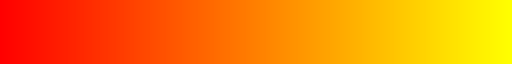

In [13]:
cmap_est

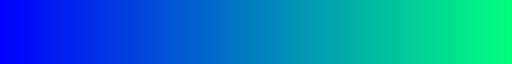

In [14]:
cmap_sur

In [ ]:
df = review_df.copy()
df_my = group_frequency_dfs_m["rare_words"]
df_my = df_my[df_my["time"] > 2022 + (10 / 12)]
df_my = df_my[df_my["section"].apply(lambda x: x in ["full", "abstract"])]

# Map each mode to a marker
marker_list = ["o", "s", "^", "D", "o", "s", "^"]
marker_map = {m: marker_list[i] for i, m in enumerate(df["mode"].unique())}

fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")

### plot my results
sns.lineplot(
    data=df_my,
    x="time",
    y="usage",
    hue="section",
    palette=colors,
    hue_order=sections,
    ax=ax,
    legend=None,
)
for sec in df_my["section"].unique():
    ax.fill_between(
        df_my[df_my["section"] == sec]["time"],
        df_my[df_my["section"] == sec]["usage"]
        - df_my[df_my["section"] == sec]["regression se (ds)"],
        df_my[df_my["section"] == sec]["usage"]
        + df_my[df_my["section"] == sec]["regression se (ds)"],
        alpha=0.2,
        color=colors[sec],
    )

###plot other results

# Plot grouped by mode (for marker control)
for mode, subdf in df.groupby("mode"):
    marker = marker_map[mode]

    # Split by method (filled vs unfilled)
    empty = subdf[subdf["method"] == "estimate"]
    filled = subdf[subdf["method"] == "survey"]

    # Filled markers
    ax.scatter(
        filled["date"],
        filled["LLM-use"],
        c=filled["color"],
        marker=marker,
        s=30,
        edgecolors="black",
        linewidths=0.75,
    )

    # Empty markers (facecolors='none')
    ax.scatter(
        empty["date"],
        empty["LLM-use"],
        facecolors="none",
        edgecolors=empty["color"],
        marker=marker,
        linewidths=1.2,
        s=30,
    )

    # Add annotations (only once per source)
    for _, row in subdf.iterrows():
        if row["annotate"]:
            """
            ax.text(
                row["date"],
                row["LLM-use"],
                str(row["source"]),
                fontsize=7,
                ha=row["ha"],
                va=row["va"],
            )"""
            x_offset = 3 if row["ha"] == "left" else -3
            y_offset = 3 if row["va"] == "bottom" else -3
            ax.annotate(
                row["source"],
                xy=(row["date"], row["LLM-use"]),
                xytext=(x_offset, y_offset),
                textcoords="offset points",
                ha=row["ha"],
                va=row["va"],
            )


### manual legend

legend_my = [
    Line2D(
        [0],
        [0],
        color=colors["abstract"],
        lw=2,
        label="abstract",
    ),
    Line2D(
        [0],
        [0],
        color=colors["full"],
        lw=2,
        label="full",
    ),
]

green = "turquoise"

legend_estimates = [
    Line2D(
        [0],
        [0],
        marker="^",
        linestyle="None",
        markerfacecolor="none",
        markeredgecolor=green,
        markeredgewidth=1.2,
        markersize=7,
        label="word frequency",
    ),
    Line2D(
        [0],
        [0],
        marker="D",
        linestyle="None",
        markerfacecolor="none",
        markeredgecolor=green,
        markeredgewidth=1.2,
        markersize=7,
        label="word freq. modeling",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        linestyle="None",
        markerfacecolor="none",
        markeredgecolor=green,
        markeredgewidth=1.2,
        markersize=7,
        label="trained detector",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor="none",
        markeredgecolor=green,
        markeredgewidth=1.2,
        markersize=7,
        label="commercial",
    ),
]

orange = "orange"

legend_surveys = [
    Line2D(
        [0],
        [0],
        marker="s",
        linestyle="None",
        markerfacecolor=orange,
        markeredgecolor="black",
        markeredgewidth=0.75,
        markersize=7,
        label="editing",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor=orange,
        markeredgecolor="black",
        markeredgewidth=0.75,
        markersize=7,
        label="writing",
    ),
    Line2D(
        [0],
        [0],
        marker="^",
        linestyle="None",
        markerfacecolor=orange,
        markeredgecolor="black",
        markeredgewidth=0.75,
        markersize=7,
        label="both",
    ),
]

section_header = lambda text: Line2D([], [], linestyle="None", label=text)

handles = (
    [section_header("Estimate $\\hat{\\beta}$")]
    + legend_my
    + [section_header("Other estimation methods")]
    + legend_estimates
    + [section_header("Surveys")]
    + legend_surveys
)

legend = ax.legend(
    handles=handles,
    loc="upper left",
    frameon=False,
    fontsize=7,
    handlelength=1.5,
    handletextpad=0.8,
    labelspacing=0.6,
)

# Make section headers bold and hide their handles
header_texts = {
    "Estimate $\\hat{\\beta}$",
    "Other estimation methods",
    "Surveys",
}

for text, handle in zip(legend.get_texts(), legend.legend_handles):

    if text.get_text() in header_texts:

        # bold
        text.set_weight("bold")

        # move header left toward marker column
        text.set_x(-30)

        # hide dummy handle
        handle.set_visible(False)

ax.set_xlabel(None)
ax.set_xticks(range(2023, 2027))
ax.set_xticklabels(range(2023, 2027))
ax.set_xlim(2022 + (11 / 12), 2026)
ax.set_ylim(0.0, 1.0)
ax.set_ylabel("LLM-use")

plt.savefig(
    os.path.join("../results/plots", BASELINE, VERSION, "study_comparison_all.png"),
    dpi=300,
)

In [ ]:
list(subdf["color"])

In [ ]:
df = review_df.copy()
df_my = group_frequency_dfs_m["rare_words"]
df_my = df_my[df_my["time"] > 2022 + (10 / 12)]
df_my = df_my[
    df_my["section"] == "full"
]  # .apply(lambda x: x in ["full", "abstract"])]

# Map each mode to a marker
marker_list = ["D", "s", "^", "v", "o", "o", "o"]
marker_map = {m: marker_list[i] for i, m in enumerate(df["mode"].unique())}

fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")

### plot my results
sns.lineplot(
    data=df_my,
    x="time",
    y="usage",
    hue="section",
    palette=colors,
    hue_order=sections,
    ax=ax,
    legend=None,
)
for sec in df_my["section"].unique():
    ax.fill_between(
        df_my[df_my["section"] == sec]["time"],
        df_my[df_my["section"] == sec]["usage"]
        - df_my[df_my["section"] == sec]["regression se (ds)"],
        df_my[df_my["section"] == sec]["usage"]
        + df_my[df_my["section"] == sec]["regression se (ds)"],
        alpha=0.2,
        color=colors[sec],
    )

###plot other results

# Plot grouped by mode (for marker control)
for mode, subdf in df.groupby("mode"):
    marker = marker_map[mode]
    if mode == "editing":
        fillstyle = "top"
    elif mode == "writing":
        fillstyle = "left"
    else:
        fillstyle = "full"

    # dummy markers for half-filled circles
    if not (fillstyle == "full"):
        ax.scatter(
            subdf["date"],
            subdf["LLM-use"],
            facecolors="none",
            marker="o",
            s=30,
            edgecolors="black",
            linewidths=0.75,
        )

    ax.scatter(
        subdf["date"],
        subdf["LLM-use"],
        c=subdf["color"],
        marker=MarkerStyle(marker, fillstyle=fillstyle),
        s=30,
        edgecolors="black",
        linewidths=0.5,
        zorder=2.5,
    )

    # Add annotations (only once per source)
    for _, row in subdf.iterrows():
        if row["annotate"]:
            """
            ax.text(
                row["date"],
                row["LLM-use"],
                str(row["source"]),
                fontsize=7,
                ha=row["ha"],
                va=row["va"],
            )"""
            x_offset = 3 if row["ha"] == "left" else -3
            y_offset = 3 if row["va"] == "bottom" else -3
            ax.annotate(
                row["source"],
                xy=(row["date"], row["LLM-use"]),
                xytext=(x_offset, y_offset),
                textcoords="offset points",
                ha=row["ha"],
                va=row["va"],
            )


### manual legend


green = "turquoise"
orange = "orange"

legend_estimates = [
    Line2D(
        [0],
        [0],
        color=colors["full"],
        lw=2,
        label="$\\hat{\\beta}$ (full paper)",
    ),
    Line2D(
        [0],
        [0],
        marker="^",
        linestyle="None",
        markerfacecolor=orange,
        markeredgecolor="black",
        markeredgewidth=0.5,
        markersize=7,
        label="word frequency",
    ),
    Line2D(
        [0],
        [0],
        marker="v",
        linestyle="None",
        markerfacecolor=orange,
        markeredgecolor="black",
        markeredgewidth=0.5,
        markersize=7,
        label="word freq. modeling",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        linestyle="None",
        markerfacecolor=orange,
        markeredgecolor="black",
        markeredgewidth=0.5,
        markersize=7,
        label="trained detector",
    ),
    Line2D(
        [0],
        [0],
        marker="D",
        linestyle="None",
        markerfacecolor=orange,
        markeredgecolor="black",
        markeredgewidth=0.5,
        markersize=7,
        label="commercial",
    ),
]

legend_surveys = [
    Line2D(
        [0],
        [0],
        marker=MarkerStyle("o", fillstyle="top"),
        linestyle="None",
        markerfacecolor=green,
        markeredgecolor="black",
        markeredgewidth=0.5,
        markersize=7,
        label="editing",
    ),
    Line2D(
        [0],
        [0],
        marker=MarkerStyle("o", fillstyle="left"),
        linestyle="None",
        markerfacecolor=green,
        markeredgecolor="black",
        markeredgewidth=0.5,
        markersize=7,
        label="writing",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor=green,
        markeredgecolor="black",
        markeredgewidth=0.5,
        markersize=7,
        label="both",
    ),
]

section_header = lambda text: Line2D([], [], linestyle="None", label=text)

handles = (
    [section_header("Indirect methods")]
    + legend_estimates
    + [section_header("Surveys")]
    + legend_surveys
)

legend = ax.legend(
    handles=handles,
    loc="upper left",
    frameon=False,
    fontsize=7,
    handlelength=1.5,
    handletextpad=0.8,
    labelspacing=0.6,
)

# Make section headers bold and hide their handles
header_texts = {
    "Indirect methods",
    "Surveys",
}

for text, handle in zip(legend.get_texts(), legend.legend_handles):

    if text.get_text() in header_texts:

        # bold
        text.set_weight("bold")

        # move header left toward marker column
        text.set_x(-30)

        # hide dummy handle
        handle.set_visible(False)

ax.set_xlabel(None)
ax.set_xticks(range(2023, 2027))
ax.set_xticklabels(range(2023, 2027))
ax.set_xlim(2022 + (11 / 12), 2026)
ax.set_ylim(0.0, 1.0)
ax.set_ylabel("LLM-use")

plt.savefig(
    os.path.join("../results/plots", BASELINE, VERSION, "study_comparison_all_v2.png"),
    dpi=300,
)

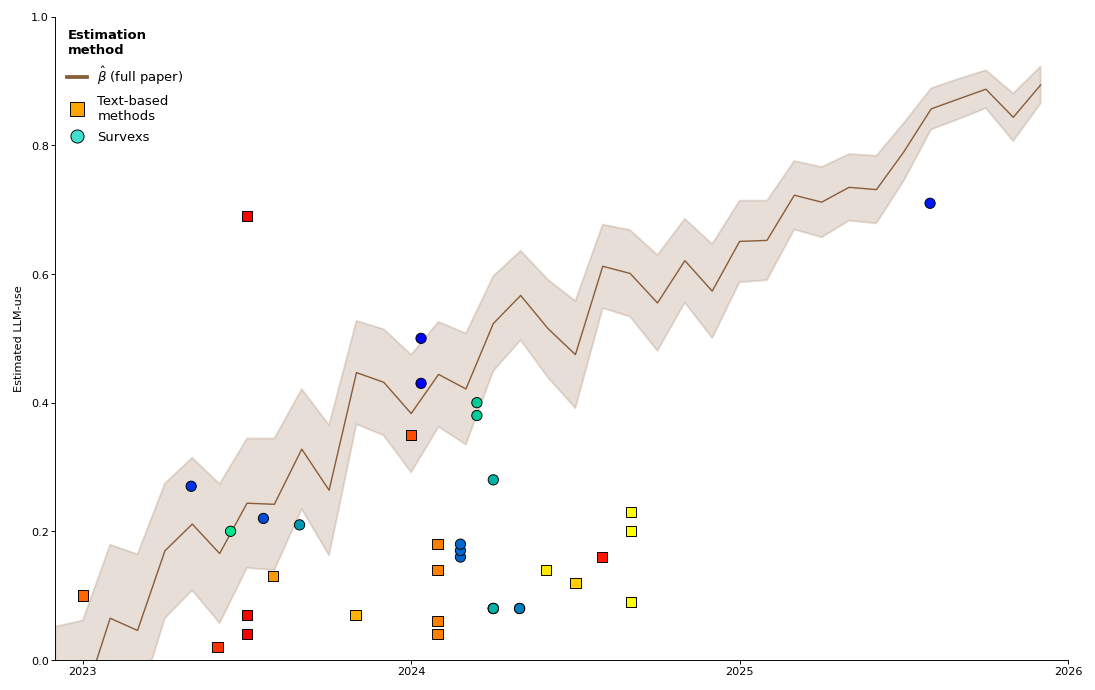

In [22]:
# version 3: reduced for presentation
df = review_df.copy()
df_my = group_frequency_dfs_m["rare_words"]
df_my = df_my[df_my["time"] > 2022 + (10 / 12)]
df_my = df_my[
    df_my["section"] == "full"
]  # .apply(lambda x: x in ["full", "abstract"])]

fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")

### plot my results
sns.lineplot(
    data=df_my,
    x="time",
    y="usage",
    hue="section",
    palette=colors,
    hue_order=sections,
    ax=ax,
    legend=None,
)
for sec in df_my["section"].unique():
    ax.fill_between(
        df_my[df_my["section"] == sec]["time"],
        df_my[df_my["section"] == sec]["usage"]
        - df_my[df_my["section"] == sec]["regression se (ds)"],
        df_my[df_my["section"] == sec]["usage"]
        + df_my[df_my["section"] == sec]["regression se (ds)"],
        alpha=0.2,
        color=colors[sec],
    )

###plot other results

# Plot grouped by method (for marker control)
for method, subdf in df.groupby("method"):
    marker = "o" if method == "survey" else "s"

    ax.scatter(
        subdf["date"],
        subdf["LLM-use"],
        c=subdf["color"],
        marker=MarkerStyle(marker),
        s=30,
        edgecolors="black",
        linewidths=0.5,
        zorder=2.5,
    )


### manual legend

green = "turquoise"
orange = "orange"

legend_estimates = [
    Line2D(
        [0],
        [0],
        color=colors["full"],
        lw=2,
        label="$\\hat{\\beta}$ (full paper)",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        linestyle="None",
        markerfacecolor=orange,
        markeredgecolor="black",
        markeredgewidth=0.5,
        markersize=7,
        label="Text-based\nmethods",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor=green,
        markeredgecolor="black",
        markeredgewidth=0.5,
        markersize=7,
        label="Survexs",
    ),
]

section_header = lambda text: Line2D([], [], linestyle="None", label=text)

handles = [section_header("Estimation\nmethod")] + legend_estimates

legend = ax.legend(
    handles=handles,
    loc="upper left",
    frameon=False,
    fontsize=7,
    handlelength=1.5,
    handletextpad=0.8,
    labelspacing=0.6,
)

# Make section headers bold and hide their handles
header_texts = {
    "Estimation\nmethod",
}

for text, handle in zip(legend.get_texts(), legend.legend_handles):

    if text.get_text() in header_texts:

        # bold
        text.set_weight("bold")

        # move header left toward marker column
        text.set_x(-30)

        # hide dummy handle
        handle.set_visible(False)

ax.set_xlabel(None)
ax.set_xticks(range(2023, 2027))
ax.set_xticklabels(range(2023, 2027))
ax.set_xlim(2022 + (11 / 12), 2026)
ax.set_ylim(0.0, 1.0)
ax.set_ylabel("Estimated LLM-use")

plt.savefig(
    os.path.join("../results/plots", BASELINE, VERSION, "study_comparison_all_v3.png"),
    dpi=300,
)

In [ ]:
df = review_df.copy()
df = df[df["section"].apply(lambda x: not (x == None))]
df_my = group_frequency_dfs_m["rare_words"]
df_my = df_my[df_my["time"] > 2022 + (10 / 12)]
df_my = df_my[
    df_my["section"].apply(lambda x: x in ["full", "abstract", "introduction"])
]

# Map each mode to a marker
marker_list = [
    "D",
    "s",
    "^",
    "v",
]
marker_map = {m: marker_list[i] for i, m in enumerate(df["mode"].unique())}

fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")

### plot my results
sns.lineplot(
    data=df_my,
    x="time",
    y="usage",
    hue="section",
    palette=colors,
    hue_order=sections,
    ax=ax,
    legend=None,
)
for sec in df_my["section"].unique():
    ax.fill_between(
        df_my[df_my["section"] == sec]["time"],
        df_my[df_my["section"] == sec]["usage"]
        - df_my[df_my["section"] == sec]["regression se (ds)"],
        df_my[df_my["section"] == sec]["usage"]
        + df_my[df_my["section"] == sec]["regression se (ds)"],
        alpha=0.2,
        color=colors[sec],
    )

###plot other results

# Plot grouped by mode (for marker control)
for mode, subdf in df.groupby("mode"):
    marker = marker_map[mode]

    # Empty markers (facecolors='none')
    ax.scatter(
        subdf["date"],
        subdf["LLM-use"],
        facecolors="none",
        edgecolors=list(map(lambda x: colors[x], subdf["section"])),
        marker=marker,
        linewidths=1.2,
        s=30,
    )

    # Add annotations (only once per source)
    for _, row in subdf.iterrows():
        if row["annotate"]:
            """
            ax.text(
                row["date"],
                row["LLM-use"],
                str(row["source"]),
                fontsize=7,
                ha=row["ha"],
                va=row["va"],
            )"""
            x_offset = 3 if row["ha"] == "left" else -3
            y_offset = 3 if row["va"] == "bottom" else -3
            ax.annotate(
                row["source"],
                xy=(row["date"], row["LLM-use"]),
                xytext=(x_offset, y_offset),
                textcoords="offset points",
                ha=row["ha"],
                va=row["va"],
            )


### manual legend

legend_my = [
    Line2D(
        [0],
        [0],
        color=colors["abstract"],
        lw=2,
        label="abstract",
    ),
    Line2D(
        [0],
        [0],
        color=colors["introduction"],
        lw=2,
        label="introduction",
    ),
    Line2D(
        [0],
        [0],
        color=colors["full"],
        lw=2,
        label="full",
    ),
]

green = colors["abstract"]

legend_estimates = [
    Line2D(
        [0],
        [0],
        marker="^",
        linestyle="None",
        markerfacecolor="none",
        markeredgecolor=green,
        markeredgewidth=1.2,
        markersize=7,
        label="word frequency",
    ),
    Line2D(
        [0],
        [0],
        marker="v",
        linestyle="None",
        markerfacecolor="none",
        markeredgecolor=green,
        markeredgewidth=1.2,
        markersize=7,
        label="word freq. modeling",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        linestyle="None",
        markerfacecolor="none",
        markeredgecolor=green,
        markeredgewidth=1.2,
        markersize=7,
        label="trained detector",
    ),
    Line2D(
        [0],
        [0],
        marker="D",
        linestyle="None",
        markerfacecolor="none",
        markeredgecolor=green,
        markeredgewidth=1.2,
        markersize=7,
        label="commercial",
    ),
]

section_header = lambda text: Line2D([], [], linestyle="None", label=text)

handles = (
    [section_header("Estimate $\\hat{\\beta}$")]
    + legend_my
    + [section_header("Other estimation methods")]
    + legend_estimates
)

legend = ax.legend(
    handles=handles,
    loc="upper left",
    frameon=False,
    fontsize=7,
    handlelength=1.5,
    handletextpad=0.8,
    labelspacing=0.6,
)

# Make section headers bold and hide their handles
header_texts = {
    "Estimate $\\hat{\\beta}$",
    "Other estimation methods",
}

for text, handle in zip(legend.get_texts(), legend.legend_handles):

    if text.get_text() in header_texts:

        # bold
        text.set_weight("bold")

        # move header left toward marker column
        text.set_x(-30)

        # hide dummy handle
        handle.set_visible(False)

ax.set_xlabel(None)
ax.set_xticks(range(2023, 2027))
ax.set_xticklabels(range(2023, 2027))
ax.set_xlim(2022 + (11 / 12), 2026)
ax.set_ylim(0.0, 1.0)
ax.set_ylabel("LLM-use")

plt.savefig(
    os.path.join(
        "../results/plots", BASELINE, VERSION, "study_comparison_sections.png"
    ),
    dpi=300,
)

In [21]:
def beta(q, p_h):
    return (q - p_h) / (1 - p_h)

In [22]:
q = 1
p_h = 0.9998
beta(q, p_h)

1.0

In [23]:
q = 0.9999
p_h = 0.9998
beta(q, p_h)

0.5

In [24]:
q * (1 - q) / 10000

9.998999999998899e-09